# Continuous TE-PAI Demo

This notebook demonstrates the Continuous TE-PAI protocol on a 2-qubit transverse-field Ising model:

$$H = Z_1 Z_2 + 0.5(X_1 + X_2)$$

We sample random circuits, evaluate each with the Qiskit backend, and compare the weighted average to the exact time evolution.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from continuous_tepai import ContinuousTEPAI, Hamiltonian, PauliString
from continuous_tepai.backends import QiskitBackend

Matplotlib is building the font cache; this may take a moment.


## 1. Define the Hamiltonian

In [3]:
H = Hamiltonian.time_independent([
    (PauliString("ZZ"), 1.0),
    (PauliString("XI"), 0.5),
    (PauliString("IX"), 0.5),
])

observable = PauliString("ZI")
T = 1.0

print(f"qubits:   {H.num_qubits}")
print(f"terms:    {H.num_terms}")
print(f"‖c‖₁ avg: {H.l1_norm_avg(T):.4f}")

qubits:   2
terms:    3
‖c‖₁ avg: 2.0000


## 2. Compute the exact value for reference

In [4]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

H_mat = np.kron(Z, Z) + 0.5 * np.kron(X, I2) + 0.5 * np.kron(I2, X)
U = expm(-1j * H_mat * T)
psi0 = np.array([1, 0, 0, 0], dtype=complex)
psi_T = U @ psi0
O_mat = np.kron(Z, I2)
exact = float(np.real(psi_T.conj() @ O_mat @ psi_T))

print(f"Exact ⟨ZI⟩(T={T}) = {exact:.6f}")

Exact ⟨ZI⟩(T=1.0) = 0.671987


## 3. Set up the sampler and backend

In [5]:
sampler = ContinuousTEPAI(H, delta=0.3, total_time=T, seed=42)
backend = QiskitBackend()

print(f"Λ (expected gate count): {sampler.expected_gate_count:.2f}")
print(f"p_Δ:                     {sampler.p_delta:.4f}")
print(f"weight prefactor:        {sampler.weight_prefactor:.4f}")

Λ (expected gate count): 13.84
p_Δ:                     0.9782
weight prefactor:        1.8304


## 4. Run the estimator

In [9]:
num_samples = 2000
values = np.empty(num_samples)

for i in range(num_samples):
    circuit = sampler.sample_circuit()
    ev = backend.expectation(circuit.rotations, observable, H.num_qubits)
    values[i] = circuit.weight * ev

mean = values.mean()
stderr = values.std(ddof=1) / np.sqrt(num_samples)

print(f"TE-PAI estimate: {mean:.6f} ± {stderr:.6f}")
print(f"Exact:           {exact:.6f}")
print(f"|error|:         {abs(mean - exact):.6f}")

TE-PAI estimate: 0.682205 ± 0.024643
Exact:           0.671987
|error|:         0.010218


## 5. Convergence plot

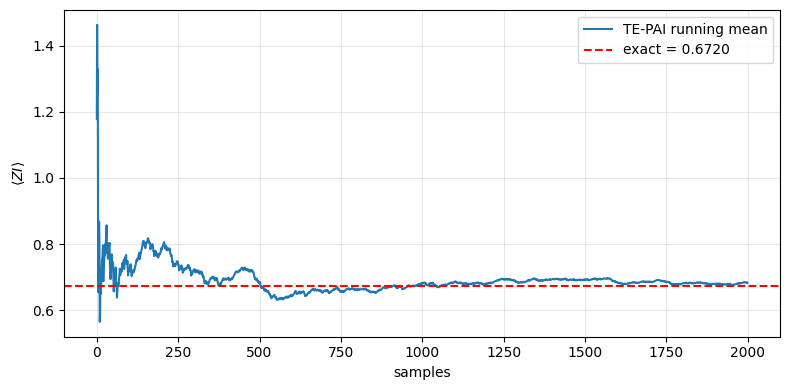

In [10]:
running_mean = np.cumsum(values) / np.arange(1, num_samples + 1)

plt.figure(figsize=(8, 4))
plt.plot(running_mean, label="TE-PAI running mean")
plt.axhline(exact, color="red", ls="--", label=f"exact = {exact:.4f}")
plt.xlabel("samples")
plt.ylabel(r"$\langle ZI \rangle$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()